En primer lugar, importamos todas las librerías necesarias:

In [3]:
#Importamos pandas
import pandas as pd 
#Importamos numpy
import numpy as np 
#Importamos datetime
import datetime as dt 

#Importación de visualizaciones
import seaborn as sns
import matplotlib.pyplot as plt

#Importamos nuestro archivo de soporte
import sys
sys.path.append('../')
from Jupyters.soporte_def import *

print ("Librerias importadas")

Librerias importadas


Importamos el dataset definitivo tras la limpieza y transformación de los datos:

In [4]:
df_original = pd.read_csv ("../Clean_Data/Dataframe_EDA.csv")
print ("Dataset importado")

Dataset importado


Por último copiamos el dataset a un dataset de trabajo:

In [5]:
df_EDA = df_original

print ("Dataset copiado")

Dataset copiado


Una vez completadas las fases de limpieza y transformación de datos, en las que se han tratado los valores nulos, eliminado los registros duplicados, verificado la consistencia de los datos, analizado los valores atípicos y aplicado las transformaciones necesarias para adaptar el dataset al análisis, el siguiente paso en el proceso es el Análisis Exploratorio de Datos (EDA).

El análisis se estructurará en cuatro bloques principales:

1. Análisis univariante: Se estudiará la distribución individual de cada variable;
2. Análisis bivariante y correlaciones: Se explorarán las relaciones entre pares de variables y  fuerza y dirección de las relaciones entre las variables del dataset.

Este análisis nos permitirá obtener una visión global y detallada del dataset, sentando las bases para la obtención de insights claros sobre la longevidad de los jugadores y el impacto de las distintas variantes sobre esta.

***1. Análisis univariante***

Lo primero que realizaremos será obtener todas las estadísticas descriptivas de las variables de nuestro dataset (ignorando los IDs) para realizar un estudio individualizado de cada una de ellas.

**Análisis de variables numéricas**

Obtenemos en primer lugar las columnas numéricas:

In [6]:
df_EDA.select_dtypes(include = np.number).columns

Index(['id', 'general_team', 'draft_team', 'seniority', 'from_year', 'to_year',
       'height_definitivo', 'weight', 'num_equipos'],
      dtype='str')

- Columna seniority

VARIABLE: seniority
 
ESTADÍSTICAS DESCRIPTIVAS
 
count    3661.00
mean        8.46
std         4.93
min         1.00
25%         4.00
50%         8.00
75%        12.00
max        22.00
Name: seniority, dtype: float64


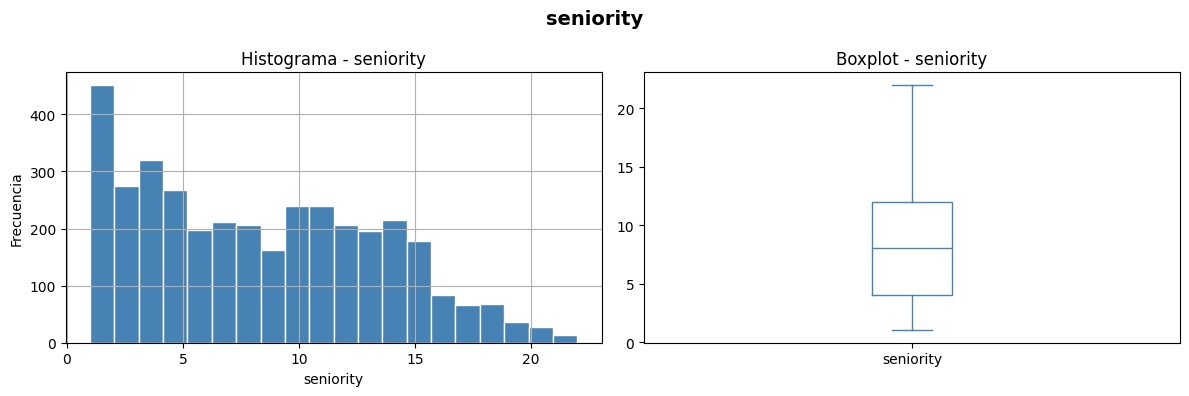

In [7]:
num_analysis(df_EDA[['seniority']])

Conclusiones: 
- El 25% de los jugadores no supera las 4 temporadas en la NBA.
- La media de temporadas en la liga es de 8,5 temporadas por jugador. 
- La mayoría de los jugadores juega entre 4 y 12 temporadas en la NBA. 
- El rango de la variable oscila entre 1 y 22 lo que nos lleva a pensar que en el conjunto de datos hay outliers debidos a carreras excepcionalmente largas de jugadores.

- Columna from_year

VARIABLE: from_year
 
ESTADÍSTICAS DESCRIPTIVAS
 
count    3661.00
mean     2008.58
std         8.12
min      1978.00
25%      2003.00
50%      2009.00
75%      2016.00
max      2022.00
Name: from_year, dtype: float64


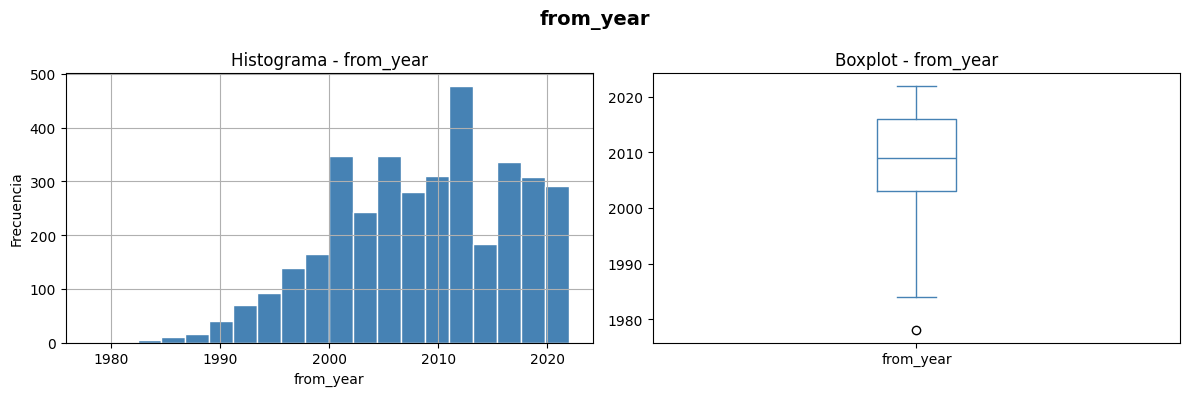

In [8]:
num_analysis(df_EDA[['from_year']])

Conclusiones:
- Le media se situa en 2008 pero realmente es una estadística descriptiva que no nos impacta ya que trataremos esta columna como categórica. 
- El 25% de los jugadores debutó antes de 2003 y el 75% lo hizo antes de 2016 lo que sugiere un flujo medianamente constante de jugadores que entran a la NBA anualmente. 
- La mayoría de nuestros registros se agrupan entre 2001 y 2017 lo que indica que la mayor parte de jugadores que conforman nuestro dataset son de la era moderna de la liga. 

- Columna to_year:

VARIABLE: to_year
 
ESTADÍSTICAS DESCRIPTIVAS
 
count    3661.00
mean     2016.12
std         6.34
min      1996.00
25%      2011.00
50%      2017.00
75%      2022.00
max      2023.00
Name: to_year, dtype: float64


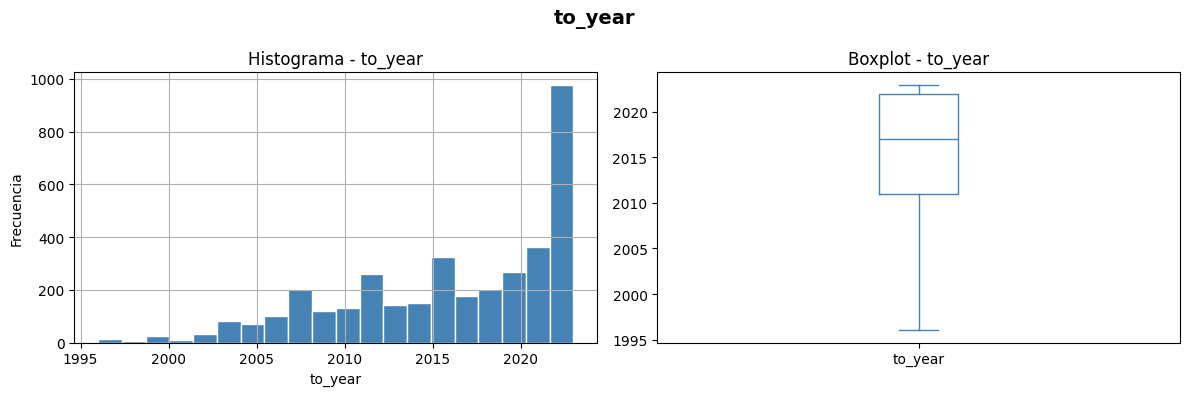

In [9]:
num_analysis(df_EDA[['to_year']])

Conclusiones: 
- El 25% de los jugadores de nuestro dataset se retiraron antes de 2011 mientras que el 75% antes de 2022 (si no es que están aún en activo). 
- Hay una concentración notable de "retiradas" en el año 2022 lo que nos indica que jugadores no retirados del dataset tienen marcado el año 2022 como año de retirada aunque no se retiraron. Es por esto que para entender la longevidad de los jugadores utilizaremos la columna de seniority que evita este problema en cierta medida.

- Columna height_definitivo

VARIABLE: height_definitivo
 
ESTADÍSTICAS DESCRIPTIVAS
 
count    3661.00
mean      200.04
std         9.06
min       165.10
25%       193.04
50%       200.66
75%       205.74
max       231.14
Name: height_definitivo, dtype: float64


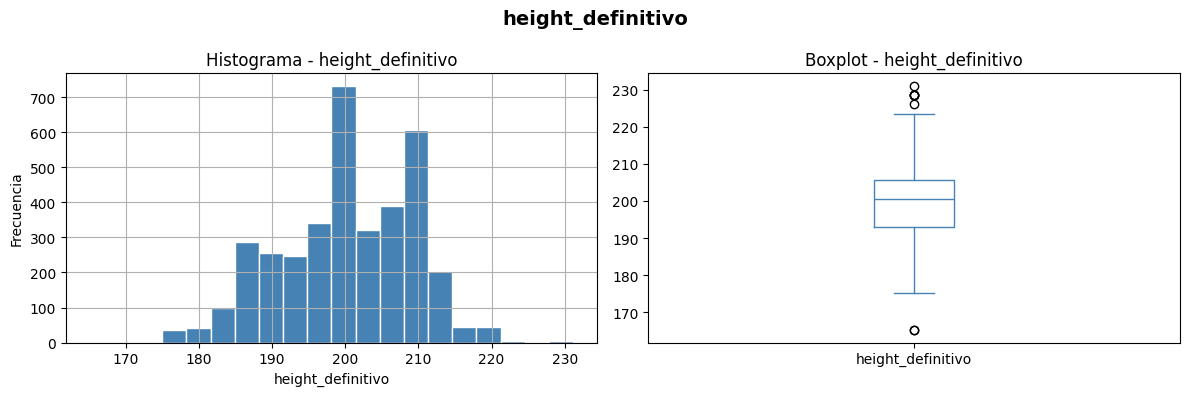

In [10]:
num_analysis(df_EDA[['height_definitivo']])

Conclusiones: 
- La media de altura de jugadores de nuestro dataset es de 200,04 cm con una desviación estándar de 9.06 lo que indica que la mayoría de jugadores tienen alturas similares que oscilan entre 193 y 206 cm. 
- El 25% de los jugadores miden menos de 193 cm mientras que el 75% no superan los 205,74 centimetros.
- Hay casos de jugadores excepcionalmente altos y excepcionalmente bajos como podemos ver en el boxplot. (Casos ya previamente vistos de jugadores que miden 231,14 cm o 165.1 cm).

- Columna weight

VARIABLE: weight
 
ESTADÍSTICAS DESCRIPTIVAS
 
count    3661.00
mean      100.19
std        12.33
min        60.30
25%        90.70
50%        99.80
75%       108.90
max       147.40
Name: weight, dtype: float64


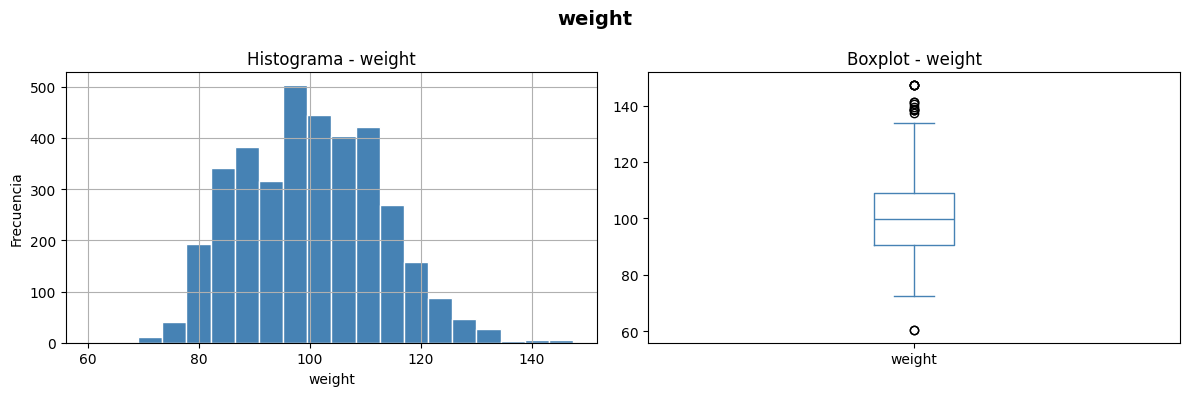

In [11]:
num_analysis(df_EDA[['weight']])

Conclusiones: 
- La media de peso de los jugadores NBA es de 100,19 KG con una desviación estándar de 12,33 KG. Por tanto, intuimos que la mayoría de los jugadores de la NBA pesan entre 90 y 109 KG en general. 
- El 25% de jugadores pesa menos de 90,7 KG mientras que el 75% no supera los 108,9 KG.
- Los valores mínimos y máximos junto al boxplot nos indican que hay presencia de outliers aunque no es una presencia muy grande.

- Columna num_equipos

VARIABLE: num_equipos
 
ESTADÍSTICAS DESCRIPTIVAS
 
count    3661.00
mean        3.32
std         1.91
min         1.00
25%         2.00
50%         3.00
75%         4.00
max        10.00
Name: num_equipos, dtype: float64


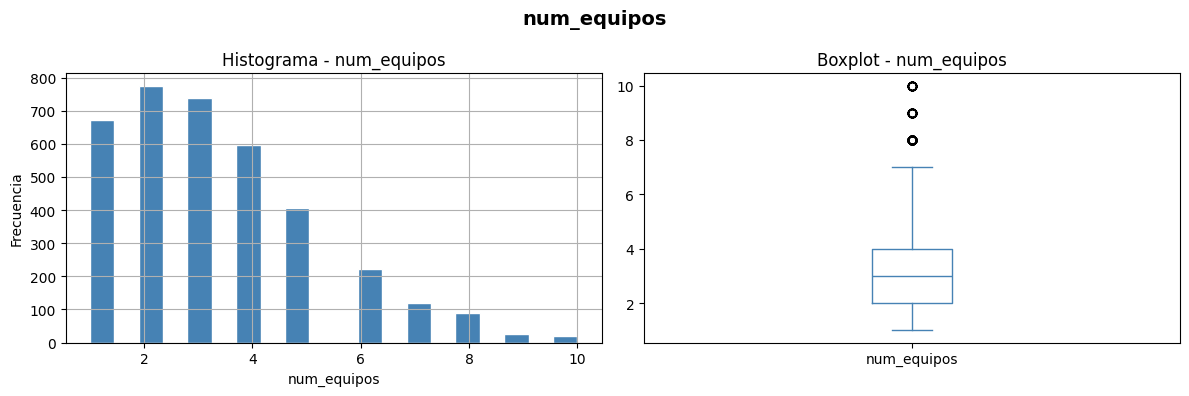

In [23]:
num_analysis(df_EDA[['num_equipos']])

Conclusiones:
- La media de equipos por jugador está en 3,32 equipos por jugador con una desviación estándar de 1,91.
- El 25% de los jugadores ha jugado en 2 o menos equipos en su carrera mientras que el 75% no supera los 4. 
- El valor máximo está en 10 equipos que representa la presencia de outliers y jugadores con una carrera muy itinerante mientras que el minimo es de 1 en los famosos one-club man, jugadores que solo jugaron en una franquicia.

**Análisis de variables categóricas**

Obtenemos las columnas categóricas ahora:

In [12]:
df_EDA.select_dtypes(include = 'object').columns

C:\Users\jdonderispla\AppData\Local\Temp\ipykernel_39656\3619424023.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_EDA.select_dtypes(include = 'object').columns


Index(['general_city', 'general_team_name', 'full_name', 'is_active',
       'draft_city', 'draft_team_name', 'organization_type', 'position',
       'g-league', 'greatest_75_flag', 'hub'],
      dtype='str')

- Columna general_city

VARIABLE: general_city
 
Número de categorías: 32
 
Distribución de frecuencias
general_city
Los Angeles      235
Houston          155
Cleveland        145
New York         141
Dallas           137
Milwaukee        134
Philadelphia     132
Atlanta          129
Boston           129
Sacramento       128
Detroit          125
Chicago          122
Washington       122
Toronto          120
Miami            118
Golden State     116
Memphis          116
Charlotte        114
Minnesota        113
San Antonio      113
New Orleans      113
Phoenix          111
Indiana          108
Utah             107
Oklahoma City    102
Portland         101
Orlando           98
Denver            91
Brooklyn          83
New Jersey        64
Seattle           37
Vancouver          2
Name: count, dtype: int64
 
Porcentajes
general_city
Los Angeles      6.42
Houston          4.23
Cleveland        3.96
New York         3.85
Dallas           3.74
Milwaukee        3.66
Philadelphia     3.61
Atlanta          3.52
Boston

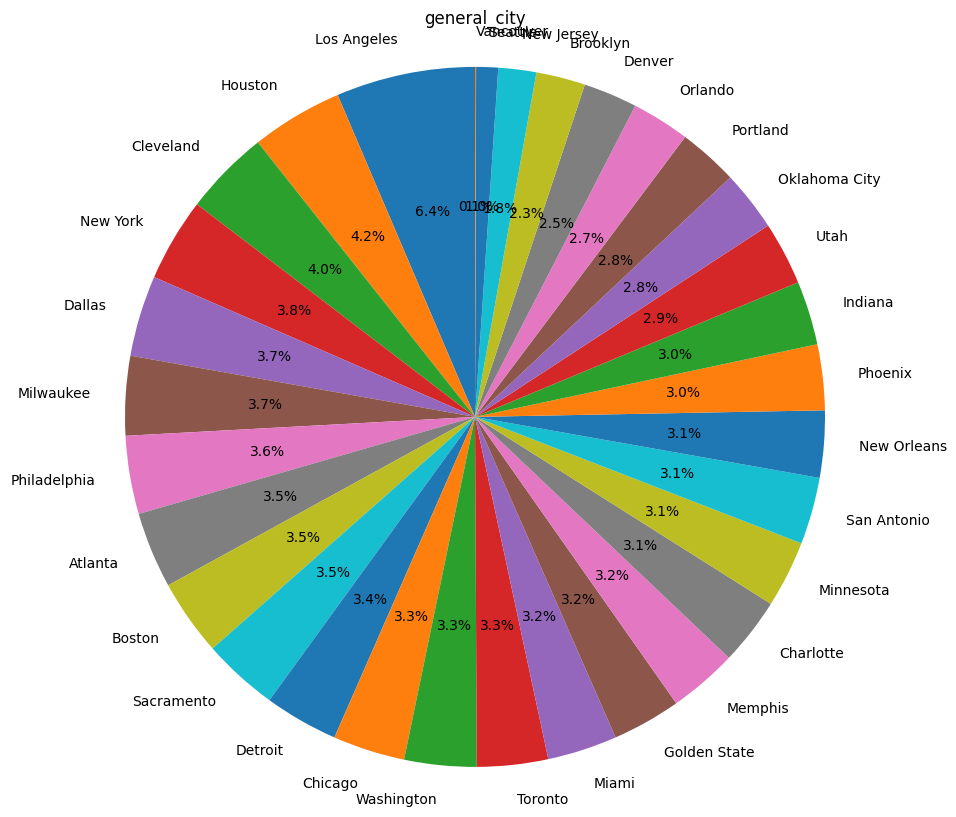

In [13]:
cat_analysis(df_EDA[['general_city']])

Conclusiones:
- La ciudad en la que más jugadores han jugado es Los Angeles, en esta ciudad han jugado un 6,42% de los jugadores históricos, esto tiene sentido ya que en Los Angeles actualmente juegan dos franquicias Lakers y Clippers. 
- Las ciudades en las que menos jugadores han jugado son Seattle (1,01%) y Vancouver (0,05%), esto también nos cuadra dado que estas ciudades albergaron históricamente a franquicias NBA (Supersonics y Grizzlies) pero actualmente no lo hacen. Visto que los datos pertenecen mayormente a jugadores de la era moderna estos datos nos cuadran. 
- La mayoría de las ciudades muestran porcentajes entre el 2,5% y el 4% lo que indica una distribución equilibrada de las ciudades en las que jugadores han jugado.

- Columna general_team_name

Esta columna va a mostrar la misma distribución o una muy similar a la anterior ya que son columnas que se interpretan en conjunto, aunque debemos tener en cuenta que ha habido franquicias que han ido mudando de ciudad por lo que vamos a analizarla aún así.

VARIABLE: general_team_name
 
Número de categorías: 32
 
Distribución de frecuencias
general_team_name
Rockets          155
Nets             147
Cavaliers        145
Knicks           141
Mavericks        137
Bucks            134
76ers            132
Hawks            129
Celtics          129
Kings            128
Pistons          125
Bulls            122
Wizards          122
Raptors          120
Heat             118
Grizzlies        118
Lakers           118
Clippers         117
Warriors         116
Timberwolves     113
Spurs            113
Suns             111
Pacers           108
Jazz             107
Thunder          102
Trail Blazers    101
Magic             98
Hornets           96
Nuggets           91
Pelicans          73
Bobcats           58
SuperSonics       37
Name: count, dtype: int64
 
Porcentajes
general_team_name
Rockets          4.23
Nets             4.02
Cavaliers        3.96
Knicks           3.85
Mavericks        3.74
Bucks            3.66
76ers            3.61
Hawks        

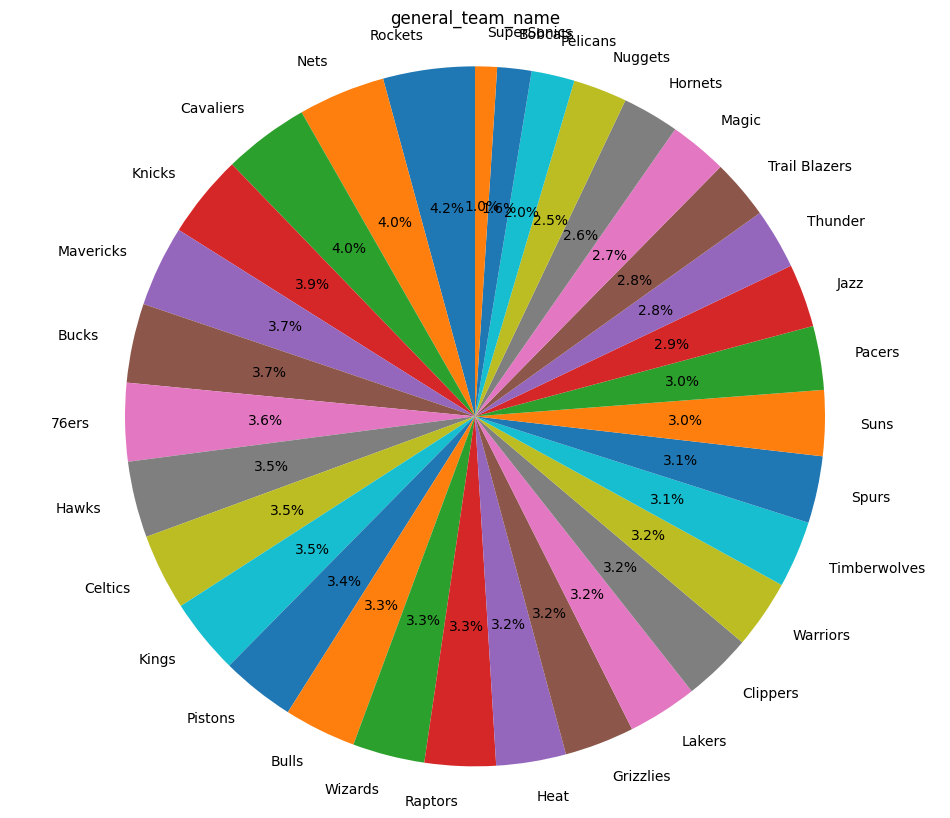

In [14]:
cat_analysis(df_EDA[['general_team_name']])

En efecto, la distribución e como podemos observar es la misma que en el caso anterior ya que si sumamos los lakers y clippers nos da el 6,4% de los angeles y el resto, cuadran. 

- Columna full_name

Esta columna no tiene sentido incluirla ya que es un identificador de cada jugador y no es realmente una columna categórica que impacte en nuestro estudio si no más bien un identificador. 

- Columna is_active

VARIABLE: is_active
 
Número de categorías: 2
 
Distribución de frecuencias
is_active
Inactive    2658
Active      1003
Name: count, dtype: int64
 
Porcentajes
is_active
Inactive    72.6
Active      27.4
Name: proportion, dtype: float64






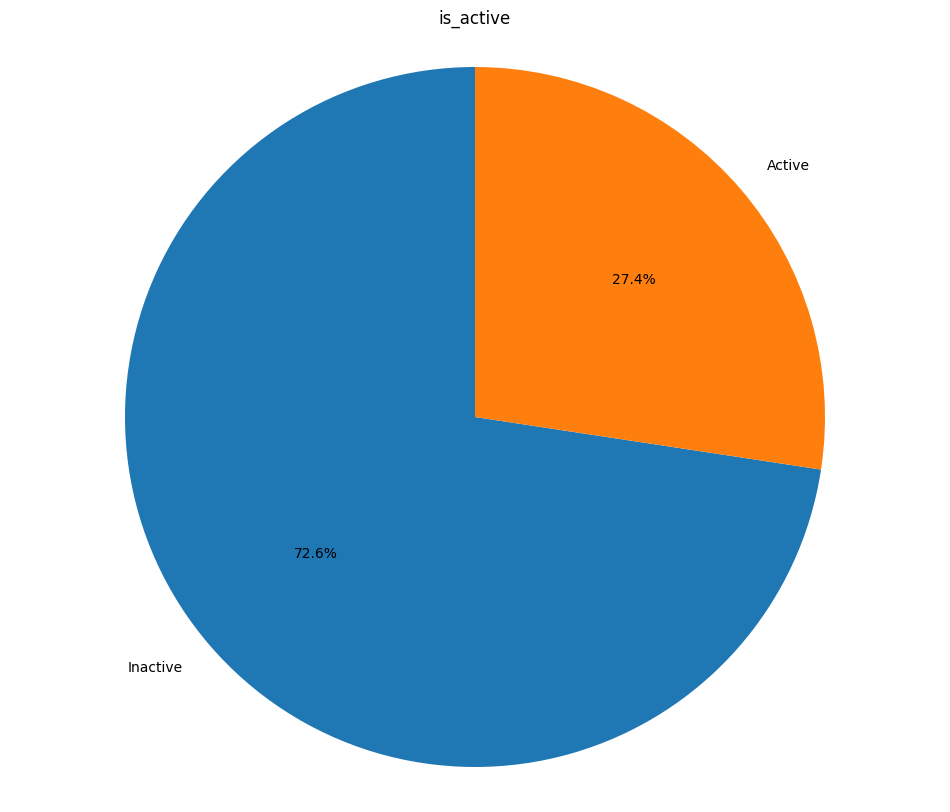

In [15]:
cat_analysis(df_EDA[['is_active']])

Conclusiones: 
- Hay un claro desbalance en la distribución entre las dos categorías que conforman el dataset, un 72,6% de los jugadores clasificados está inactivo mientras que un 27,4% de los jugadores está activo. Es decir en nuestro dataset hay aproximadamente 3 jugadores inactivos por cada jugador activo. 
Este es un desbalanceo esperado ya que como ya sabíamos el dataset incluye muchos jugadores históricos que ya se han retirado. Esto también tendremos que tenerlo en cuenta si al final incluimos la columna en el estudio de correlaciones.

- Columna draft_city y draft_team_name

VARIABLE: draft_city
 
Número de categorías: 33
 
Distribución de frecuencias
draft_city
Undrafted        864
Los Angeles      163
Boston           136
Philadelphia     128
Sacramento       126
Detroit          120
Atlanta          111
Phoenix          107
Cleveland        107
Chicago          100
Milwaukee         97
Utah              96
Orlando           94
Charlotte         93
Indiana           92
New York          91
Minnesota         90
Memphis           89
Golden State      87
Houston           86
Denver            85
Washington        83
Portland          80
Dallas            70
New Orleans       70
Miami             67
San Antonio       66
Seattle           61
New Jersey        58
Toronto           57
Oklahoma City     45
Brooklyn          26
Vancouver         16
Name: count, dtype: int64
 
Porcentajes
draft_city
Undrafted        23.60
Los Angeles       4.45
Boston            3.71
Philadelphia      3.50
Sacramento        3.44
Detroit           3.28
Atlanta           3.03
Phoeni

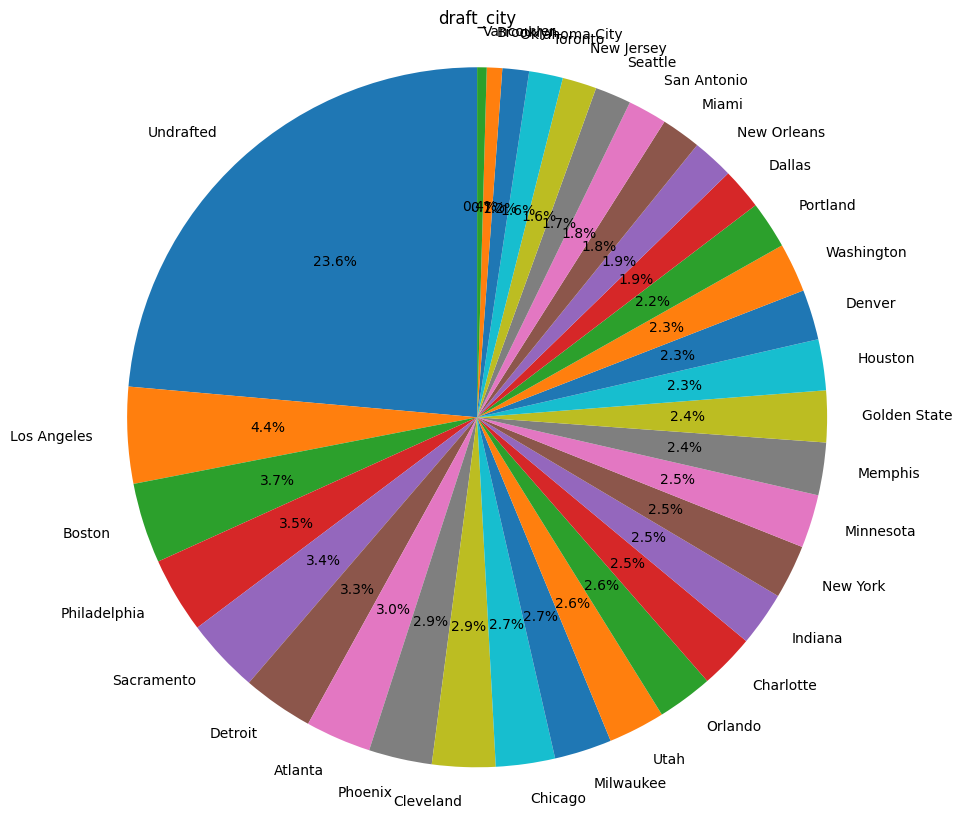

In [16]:
cat_analysis(df_EDA[['draft_city']])

Conclusiones: 
- Los más destacable de esta columna es que un 23,6% de los jugadores no fue drafteado por ningún equipo lo que nos lleva a destacar que 1 de cada 4 jugadores no llegó a la NBA via draft si no a través de vias alternativas. Esto destaca que realmente las vias alternativas de acceso a la liga son realmente importantes.
- Las ciudades en las que más jugadores drafteados han habido son Los Angeles 4,45% (debido a las dos franquicias), Boston 3,71% y Philadelphia 3,5%. 
- La mayoría de equipos presenta entre un 2% y un 3,5% de jugadores drafteados del total del dataset lo que demuestra una distribución equilibrada de las elecciones del draft (Las diferencias en porcentajes provienen del mercadeo con elecciones del draft en traspasos de jugadores).
- En el extremo inferior de nuevo encontramos a Vancouver con un 0,44% debido a la corta duración de la franquicia antes del traslado y Brooklyn con un 0,71% debido a que es una franquicia relativamente nueva.

VARIABLE: draft_team_name
 
Número de categorías: 34
 
Distribución de frecuencias
draft_team_name
Undrafted        864
Celtics          136
76ers            128
Kings            126
Pistons          120
Hawks            111
Suns             107
Cavaliers        107
Grizzlies        105
Bulls            100
Bucks             97
Jazz              96
Magic             94
Hornets           93
Pacers            92
Knicks            91
Timberwolves      90
Warriors          87
Clippers          87
Rockets           86
Nuggets           85
Nets              84
Trail Blazers     80
Lakers            76
Wizards           74
Mavericks         70
Heat              67
Spurs             66
SuperSonics       61
Raptors           57
Bobcats           48
Thunder           45
Pelicans          22
Bullets            9
Name: count, dtype: int64
 
Porcentajes
draft_team_name
Undrafted        23.60
Celtics           3.71
76ers             3.50
Kings             3.44
Pistons           3.28
Hawks           

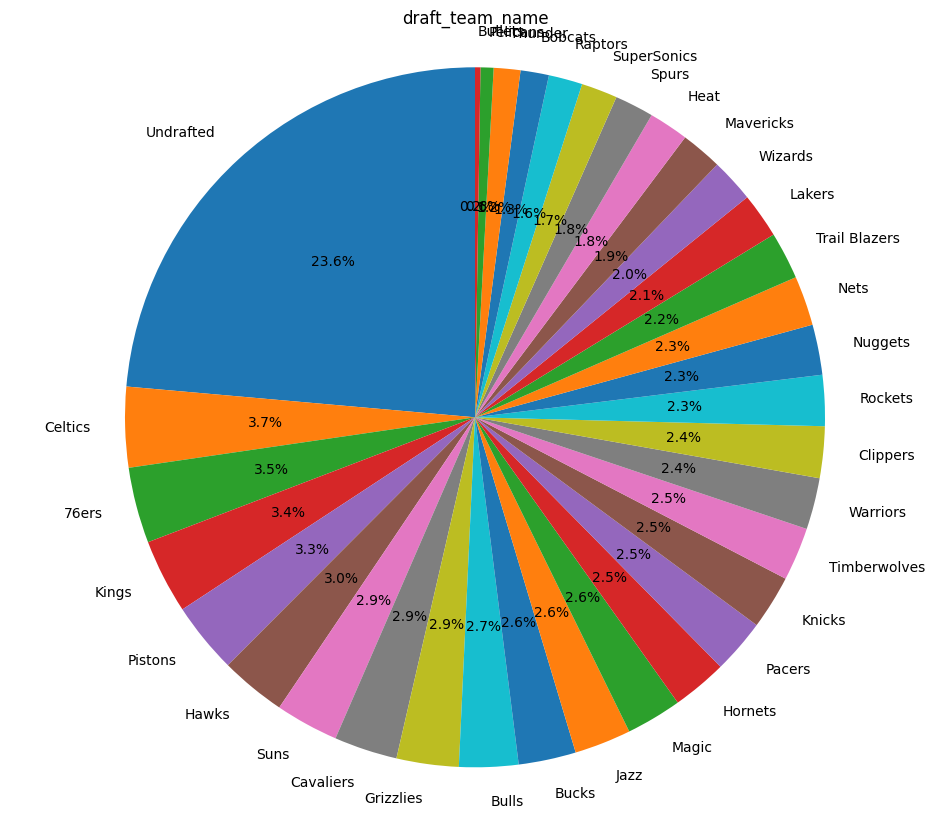

In [17]:
cat_analysis(df_EDA[['draft_team_name']])

La distribución de las variables es prácticamente la misma que en el caso anterior por lo que no profundizaremos en esta como hemos hecho anteriormente.

- Columna organization_type

VARIABLE: organization_type
 
Número de categorías: 4
 
Distribución de frecuencias
organization_type
College/University    2364
Unknown                866
Other Team/Club        307
High School            124
Name: count, dtype: int64
 
Porcentajes
organization_type
College/University    64.57
Unknown               23.65
Other Team/Club        8.39
High School            3.39
Name: proportion, dtype: float64






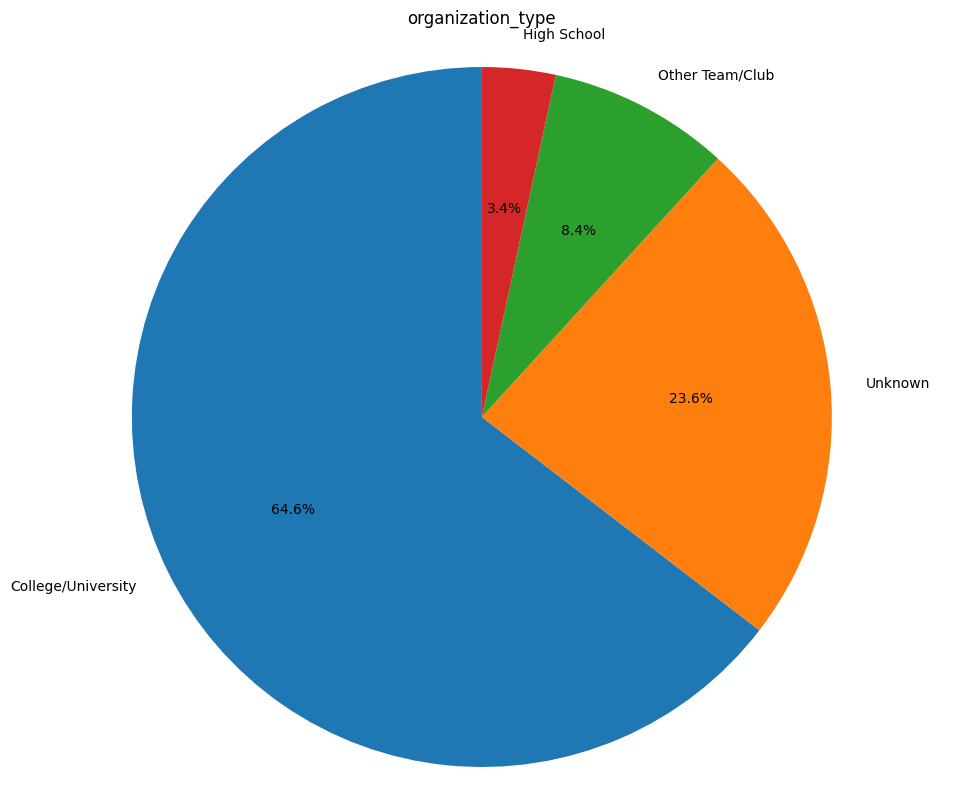

In [18]:
cat_analysis(df_EDA[['organization_type']])

Conclusiones: 
- La categoría más frecuente es la de College/university con un 64,57% indicando que la mayoría de jugadores vienen de ligas universitarias. Esto destaca la importancia del sistema universitario para la NBA y la tradición del baloncesto universitario utilizando la NCAA como "cantera". 
- En segundo lugar, tenemos la categoría Unknown imputada durante la limpieza de este dataset al tener un porcentaje relevante la tendremos que tener en cuenta a la hora de interpretar resultados.
- Por último tenemos Team/Club con un 8,39% que incluye a los jugadores provenientes de ligas profesionales de otros países y High School donde solo un selecto club de jugadores pegaron el salto del instituto a la liga. Además, esta práctica se prohibió en el año 2005 lo que también justifica su escasa incidencia.

- Columna position

VARIABLE: position
 
Número de categorías: 7
 
Distribución de frecuencias
position
Guard             1340
Forward           1079
Center             437
Guard-Forward      289
Forward-Center     250
Center-Forward     154
Forward-Guard      112
Name: count, dtype: int64
 
Porcentajes
position
Guard             36.60
Forward           29.47
Center            11.94
Guard-Forward      7.89
Forward-Center     6.83
Center-Forward     4.21
Forward-Guard      3.06
Name: proportion, dtype: float64






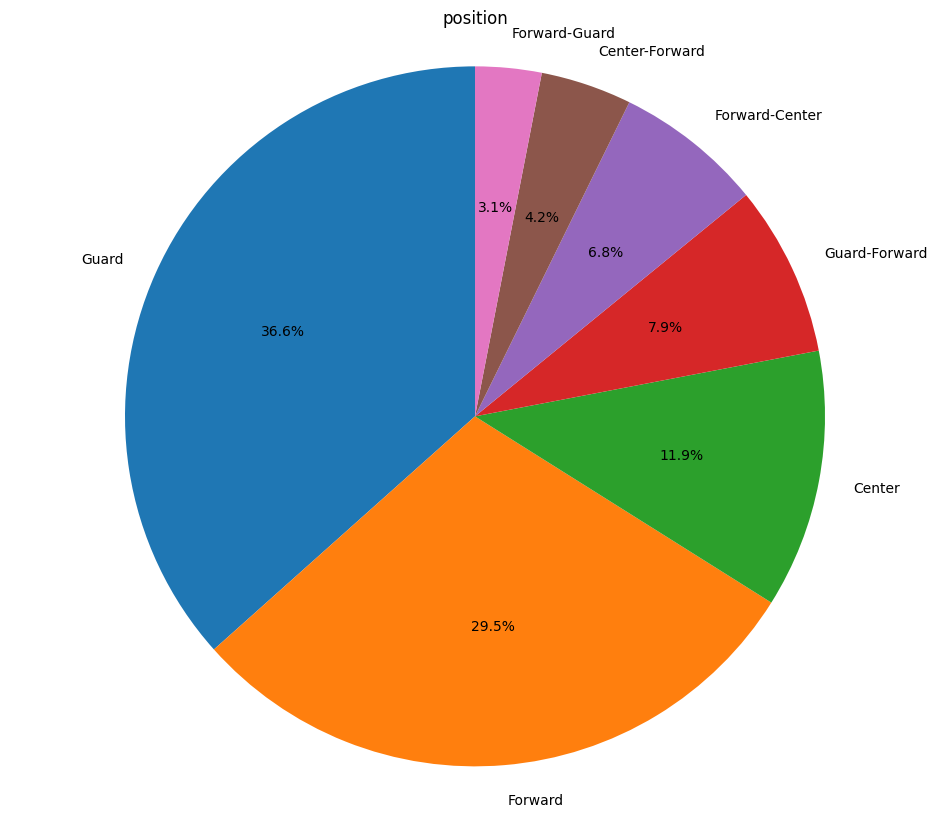

In [19]:
cat_analysis(df_EDA[['position']])

Conclusiones:
- Lo primero que podemos observar en el dataset es que hay un claro dominio de los jugadores que juegan en posiciones puras (una sola posición) con un 78,01% de dominancia por encima de los jugadores que ocupan posiciones mixtas con un 21,99% (jugadores que pueden jugar en más de una posición). Esto hace a los jugadores en posiciones mixtas más valorados por su escasez y su capacidad de ocupar más de una posición en el campo. 
- La posición más ocupada por los jugadores suele ser la de guard (Base o Escolta en baloncesto moderno) con un 36,6% de los jugadores ocupandola. De cerca le sigue la posición de Forward con un 29,5% (Alero o Ala-Pivot en baloncesto moderno) y en tercer lugar, los centers (pivots en baloncesto moderno) que representan el 11,9% de los jugadores del dataset.
Esta diferencia entre las dos primeras posiciones y la tercera se debe a que en las dos primera categorías los jugadores pueden ocupar realmente dos posiciones en el campo mientras que en la tercera una sola.
- Las posiciones más extrañas son la de Forward-Guard (Aleros con habilidades para tirar de 3 o distribuir el balón) con un 3,1% de los jugadores lo que los hace jugadores realmente especiales dado al tamaño que suelen tener y su repertorio de habilidades. Y la segunda posición más extraña es la de Center-Forward (pivots con habilidades para penetrar a canasta o tirar de 3) con un 4,2% lo que también como en el caso anterior los hace jugadores muy especiales. 

- Columna g-league

VARIABLE: g-league
 
Número de categorías: 2
 
Distribución de frecuencias
g-league
Yes    1904
No     1757
Name: count, dtype: int64
 
Porcentajes
g-league
Yes    52.01
No     47.99
Name: proportion, dtype: float64






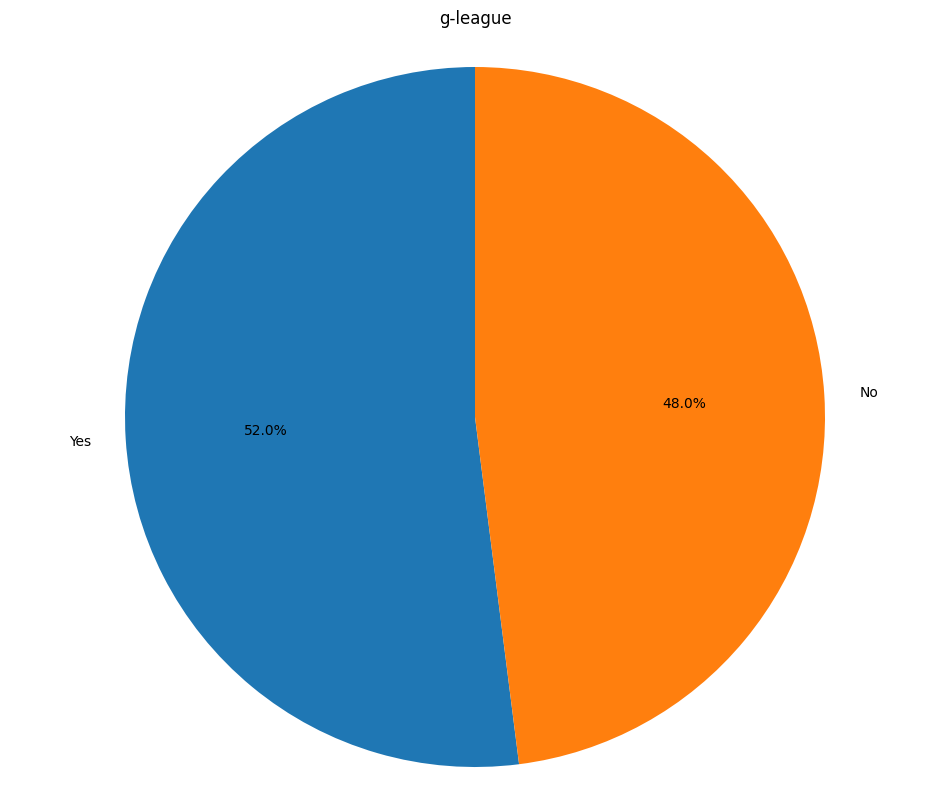

In [20]:
cat_analysis(df_EDA[['g-league']])

Conclusiones: 
- La distribución de esta variable está muy equilibrada entre ambas categorías con un 52,01% de los jugadores habiendo pasado por la g-league y el 47,99% restante no. Esto refleja la importancia que tiene la g-league en el desarrollo de los jugadores y/o su acceso a la liga. 

- Columna greatest_75_flag

VARIABLE: greatest_75_flag
 
Número de categorías: 2
 
Distribución de frecuencias
greatest_75_flag
No     3605
Yes      56
Name: count, dtype: int64
 
Porcentajes
greatest_75_flag
No     98.47
Yes     1.53
Name: proportion, dtype: float64






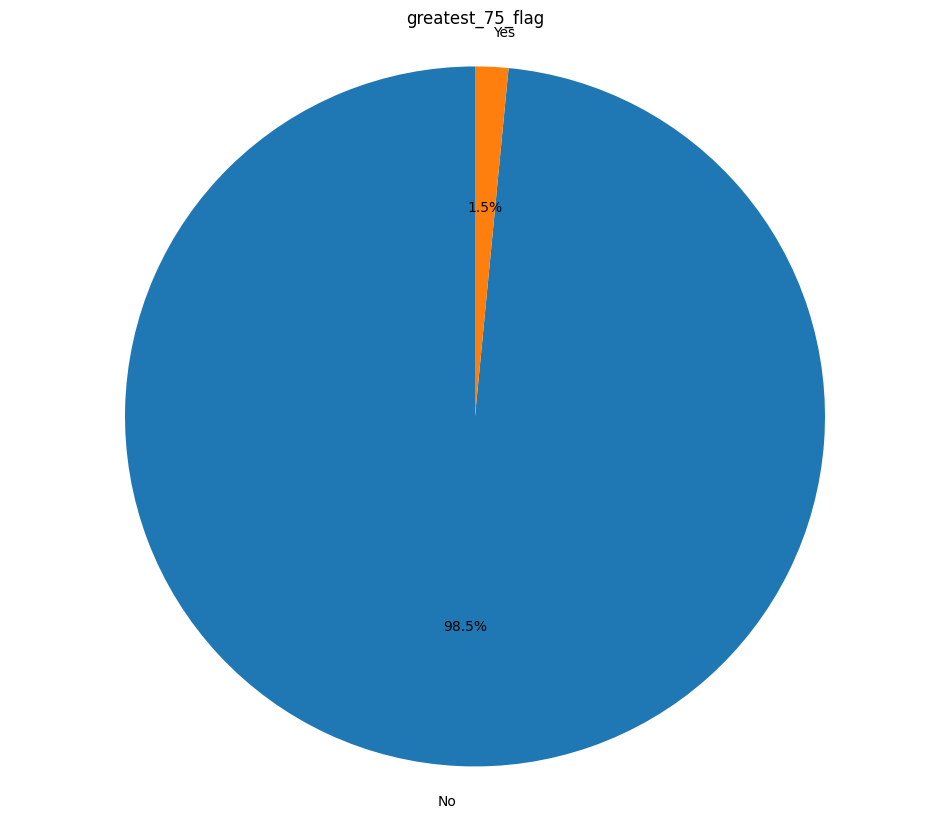

In [21]:
cat_analysis(df_EDA[['greatest_75_flag']])

Conclusiones: 
- Esta variable tiene un esperable desbalanceo ya que solo 75 jugadores pertenecen al club de los más grandes de la historia. Lo único destacable de esta categoría es la distribución que presenta ya que solo un 1,5% de los jugadores están en esa lista. 
- Cabe también destacar que estos jugadores presentarán una longevidad mayor en la liga ya que son reconocidos como los mejores jugadores de la historia pero veremos posteriormente cuanto es de influyente estar en esta lista en términos de longevidad.

- Columna hub

VARIABLE: hub
 
Número de categorías: 9
 
Distribución de frecuencias
hub
USA               3019
Eastern Europe     228
Western Europe     145
Africa              73
North America       60
Latin America       57
Oceania             44
Caribbean           24
Asia                11
Name: count, dtype: int64
 
Porcentajes
hub
USA               82.46
Eastern Europe     6.23
Western Europe     3.96
Africa             1.99
North America      1.64
Latin America      1.56
Oceania            1.20
Caribbean          0.66
Asia               0.30
Name: proportion, dtype: float64






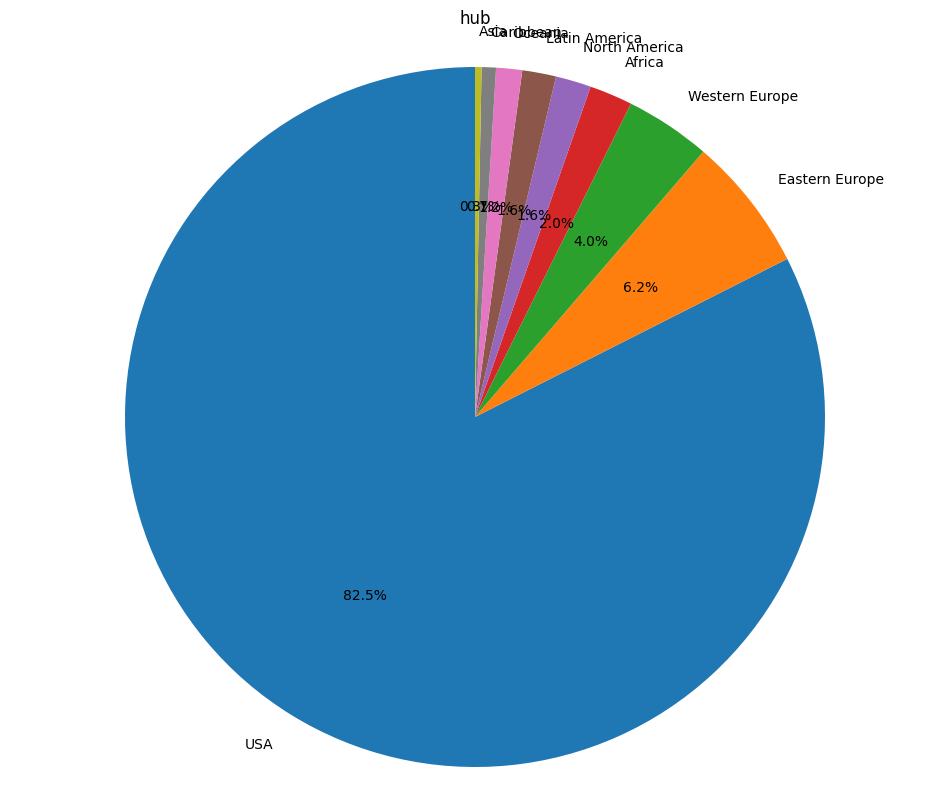

In [22]:
cat_analysis(df_EDA[['hub']])

Conclusiones: 
- Esta columna presenta un gran desbalanceo con un 82,5% de los jugadores históricos proveniendo de USA. La segunda región de la que más jugadores provienen es de Europa con un 6,23% provenientes de Europa del Este y un 3,96% de Europa del Oeste este dato no sorprende ya que Europa es y ha sido la fabrica de muchos grandes jugadores de la liga. 
- Por último es también notable la influencia que tiene la NBA en Africa con un 2% de jugadores proveniendo de esta región. 
- También destacar que para considerar a la NBA como una liga totalmente internacional pueden explotar más su mercado asiático con solo un 0,3% de los jugadores proveniendo de allí. 

Con esto concluye el análisis univariante. Seguidamente, procederemos al análisis de correlaciones y bivariantes en el siguiente Jupyter. 